# Visualizing Commonality

1. Load Fusion files of all subjects
2. Make mask-image based on highest commonality coefficitiens (with a certain % threshold)
3. Sum the subject-specific mask images to visuales location of highest commonalities 

In [1]:
import sys
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')

from glob import glob

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from nilearn import plotting
from nilearn.image import new_img_like
from scipy.ndimage import label

from utils.load_cfg import load_fusion_config_instance
from utils.subj import *

## Function to create the masks and plot the data

In [3]:
def _get_mappable(max):
	norm = mpl.colors.Normalize(vmin=0,vmax=max)
	return plt.cm.ScalarMappable(cmap='inferno', norm=norm)

def plot_commonality(fusionFiles, modality, thres, time, mask):
	n_slices = 8
	fig, axes = plt.subplots(ncols=1, nrows=len(time), figsize=(7, 3)) # , subplot_kw={'projection': '3d'})

	for n, t in enumerate(time):
		print(t)
		times = np.arange(-1000, 1000, 10)
		subj_mask_data = []

		for file in fusionFiles[:1]:

			fusion = joblib.load(file)
			t_data = fusion['data'][t][modality] #fusion data of time point 130 for current modality
			fusion_idx = fusion['voxel_index_py']

			data_1d = np.zeros(mask.shape).flatten()
			data_1d[fusion_idx] = t_data
			data_3d = data_1d.reshape(mask.shape)
			threshold = np.nanpercentile(t_data, thres)

			tmp_mask_img = np.zeros(mask.shape)
			tmp_mask_img[data_3d > threshold] = 1
			subj_mask_data.append(tmp_mask_img)

		subj_mask_array = np.sum(np.array(subj_mask_data), axis=0)
		subj_mask_img = new_img_like(mask, subj_mask_array)

 
		display = plotting.plot_stat_map(
			subj_mask_img, 
			colorbar=True, 
			threshold=threshold,
			cut_coords=8,
			display_mode='z', 
			draw_cross=False, 
			# title=f'time: {times[t]} ms',
			figure=fig,
			cmap='inferno',
			black_bg=False, 
			annotate=False,
			axes=axes[n]
		)
		axes[n].set_title(times[t])
		axes[n].title.set_horizontalalignment('left')
	# fig.subplots_adjust(right=0.8)
	# cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
	plt.colorbar(display, ax=axes, orientation='vertical')
	plt.suptitle(modality, y=1.05)
	plt.show()
	# return display

def load_all_files(config_class_name = 'FusionConfig_C5', meanMEG = False):
	cfg = load_fusion_config_instance(config_class_name) # since no subject ID is specified, '*' will be used --> creates pattern with subject-wildcard instead of subject filename 

	if meanMEG:
		fusionFiles = sorted(glob(cfg.get_outFile_names()['fusion_mean_pkl']))
	else:  
		fusionFiles = sorted(glob(cfg.get_outFile_names()['fusion_pkl']))

	print(f'number of subjects: {len(fusionFiles)}')
	
	full_data=[]
	for file in fusionFiles:
		fusion = joblib.load(file)
		full_data.append(fusion)

	mask = nib.load(cfg.maskFile)
	return full_data, mask

def plot_commonality_new(full_data, thres, mask, plot_time = [125, 130]):
	
	# print(f"Threshold: {thres} %", flush=True)
	time = np.arange(0, 200, 1)
	# mask = nib.load(cfg.maskFile)

	# plot_commonality(fusionFiles, modality, thres, time, mask)

	time = np.arange(0, 200, 1)
	fusion_data_90={}
	for m, modality in enumerate(ALL_MODELS):
		# print(modality)
		data=[]
		for n, t in enumerate(time):
			# print(t)
			subj_mask_data = []

			for fusion in full_data:
				t_data = fusion['data'][t][modality] #fusion data of time point 130 for current modality
				fusion_idx = fusion['voxel_index_py']

				data_1d = np.zeros(mask.shape).flatten()
				data_1d[fusion_idx] = t_data
				data_3d = data_1d.reshape(mask.shape)
				threshold = np.nanpercentile(t_data, thres)

				tmp_mask_img = np.zeros(mask.shape)
				tmp_mask_img[data_3d > threshold] = 1
				subj_mask_data.append(tmp_mask_img)

			subj_mask_array = np.sum(np.array(subj_mask_data), axis=0)
			subj_mask_img = new_img_like(mask, subj_mask_array)
			data.append(subj_mask_img)
		fusion_data_90[modality]=data

	
	times = np.arange(-1000, 1000, 10)
	cols = ALL_MODELS
	rows = [str(t) for t in times[plot_time]]

	plt.close()

	fig, axes = plt.subplots(ncols=2, nrows=len(plot_time), figsize=(20,6)) # , subplot_kw={'projection': '3d'})

	for m, modality in enumerate(ALL_MODELS):
		for n, t in enumerate(plot_time):
			# print(t)

			subj_mask_img = fusion_data_90[modality][t]

			plotting.plot_stat_map(
				subj_mask_img, 
				colorbar=False, 
				threshold=threshold,
				cut_coords=8,
				display_mode='z', 
				draw_cross=False, 
				figure=fig,
				cmap='inferno',
				black_bg=True, 
				annotate=False,
				axes=axes[n, m],
				title = f"{modality} {(t-100)*10} ms"
			)
	fig.show
	# fig_original=deepcopy(fig)
	# axes_original=deepcopy(axes)

def plot_commonality_mean(full_data, thres, mask, plot_time = [125, 130], do_plot=True):
	
	time = np.arange(0, 200, 1)

	fusion_mean={}
	for m, modality in enumerate(ALL_MODELS):
		# print(modality)
		fusion_all_subj=[]
		for n, t in enumerate(time):
			fusion_all_subj.append([])

			for fusion in full_data:
				t_data = fusion['data'][t][modality] #fusion data of time point 130 for current modality
				fusion_idx = fusion['voxel_index_py']

				data_1d = np.zeros(mask.shape).flatten()
				data_1d[fusion_idx] = t_data
				data_3d = data_1d.reshape(mask.shape)
				fusion_all_subj[n].append(data_3d)

		fusion_mean[modality]=np.nanmean(np.stack(fusion_all_subj).transpose(2, 3, 4, 0, 1), axis = -1)

	if do_plot:
		fig, axes = plt.subplots(ncols=2, nrows=len(plot_time), figsize=(20,6)) # , subplot_kw={'projection': '3d'})

		for m, modality in enumerate(ALL_MODELS):
			for n, t in enumerate(plot_time):
				# print(t)
				t_data = fusion_mean[modality][:,:,:,t]
				mean_img_t = new_img_like(mask, t_data)
				threshold = np.nanpercentile(t_data, thres)

				plotting.plot_stat_map(
					mean_img_t, 
					colorbar=True, 
					threshold=threshold,
					cut_coords=8,
					display_mode='z', 
					draw_cross=False, 
					figure=fig,
					cmap='inferno',
					black_bg=True, 
					annotate=False,
					axes=axes[n, m],
					title = f"{modality} {(t-100)*10} ms"
				)
		fig.show
	return fusion_mean

def plot_workflow(full_data, mask, thres = [90, 95], plot_time = [125, 130], plot_ss_thr_masks = True, plot_mean_commonality = True):
	
	## A) Sum of subj-level threshold binary masks
	if plot_ss_thr_masks:
		for thr in thres:
			# print(f"Threshold: {thr} %", flush=True)
			plot_commonality_new(full_data, thr, mask, plot_time)

	## B) Mean of subject commonalities
	if plot_mean_commonality:
		for thr in thres:
			# print(f"Threshold: {thr} %", flush=True)
			plot_commonality_mean(full_data, thr, mask, plot_time)

# Crossnobis

### Config: C5

A) No MEG mean


Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default

Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default
Threshold: 95 %
sensory
suprasensory
Threshold: 99 %
sensory
suprasensory


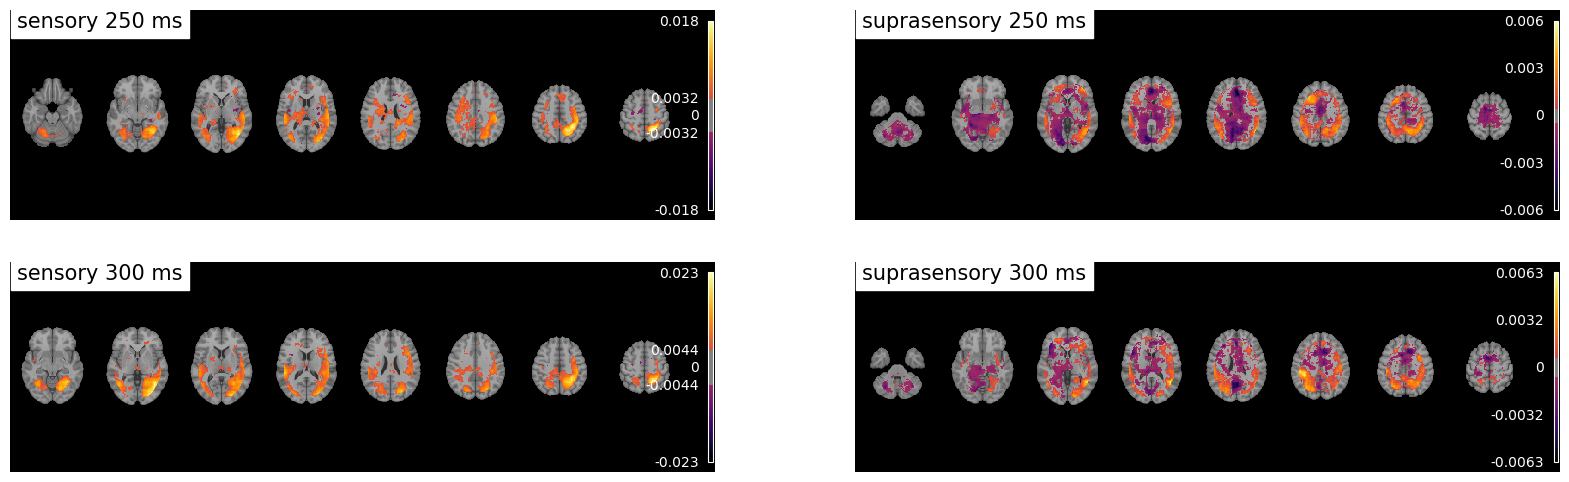

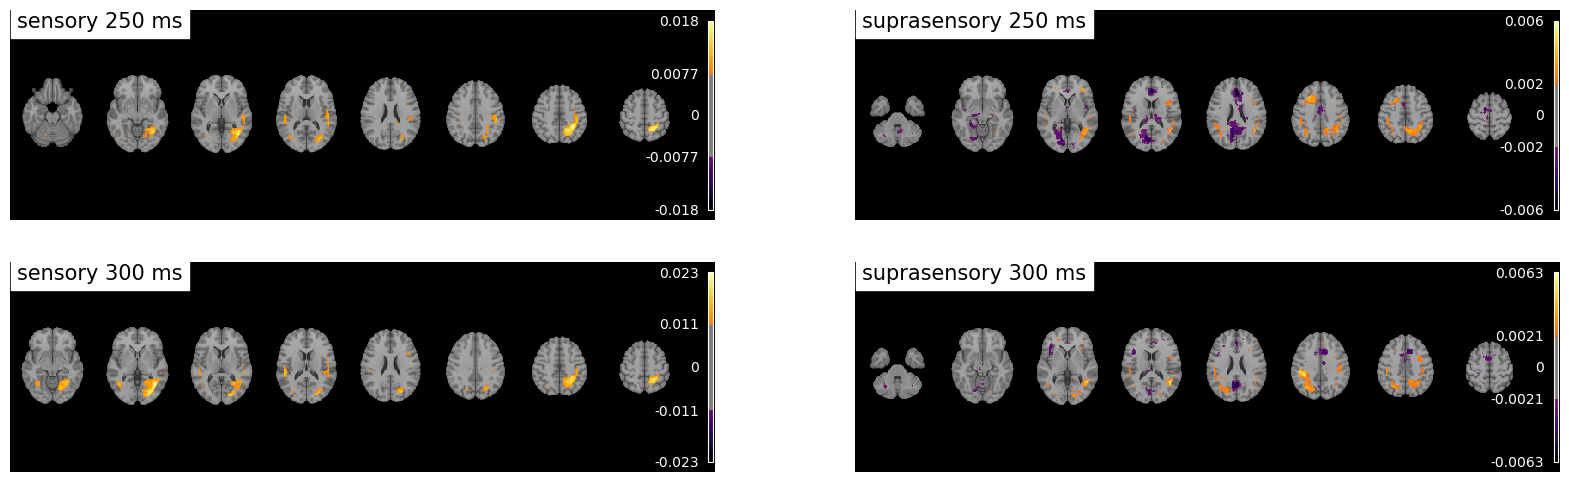

In [4]:
config_class_name = 'FusionConfig_C5'
meanMEG = False

full_data, mask = load_all_files(config_class_name, meanMEG)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)

B) MEG mean


Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default

Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default
Threshold: 95 %
sensory
suprasensory
Threshold: 99 %
sensory
suprasensory


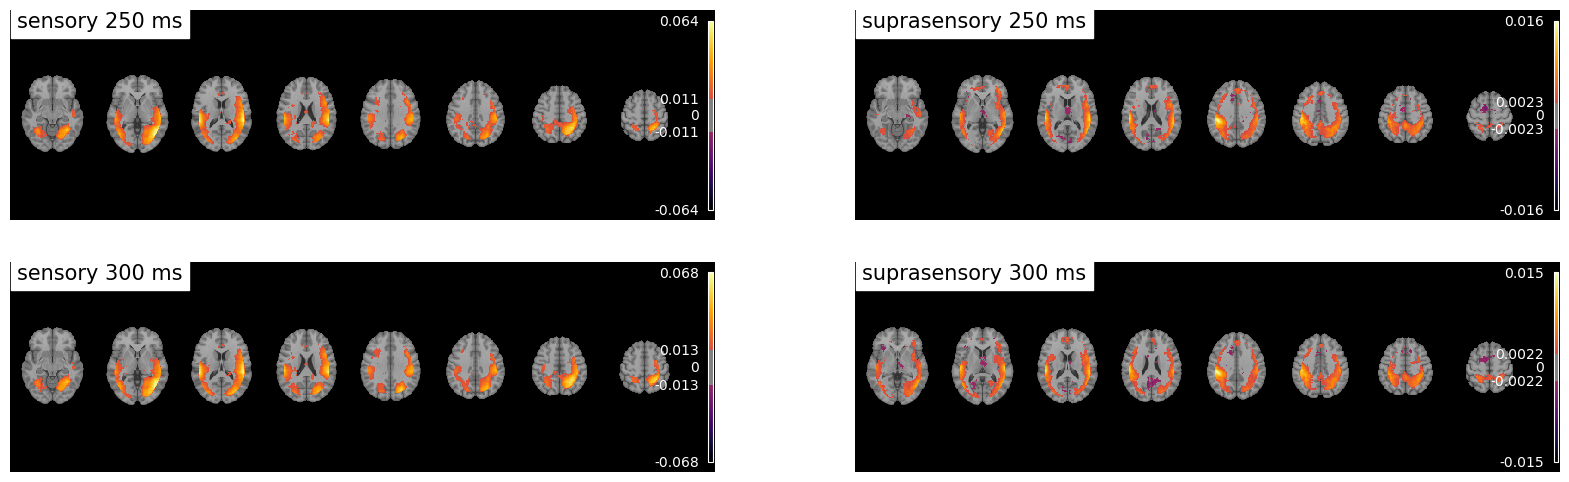

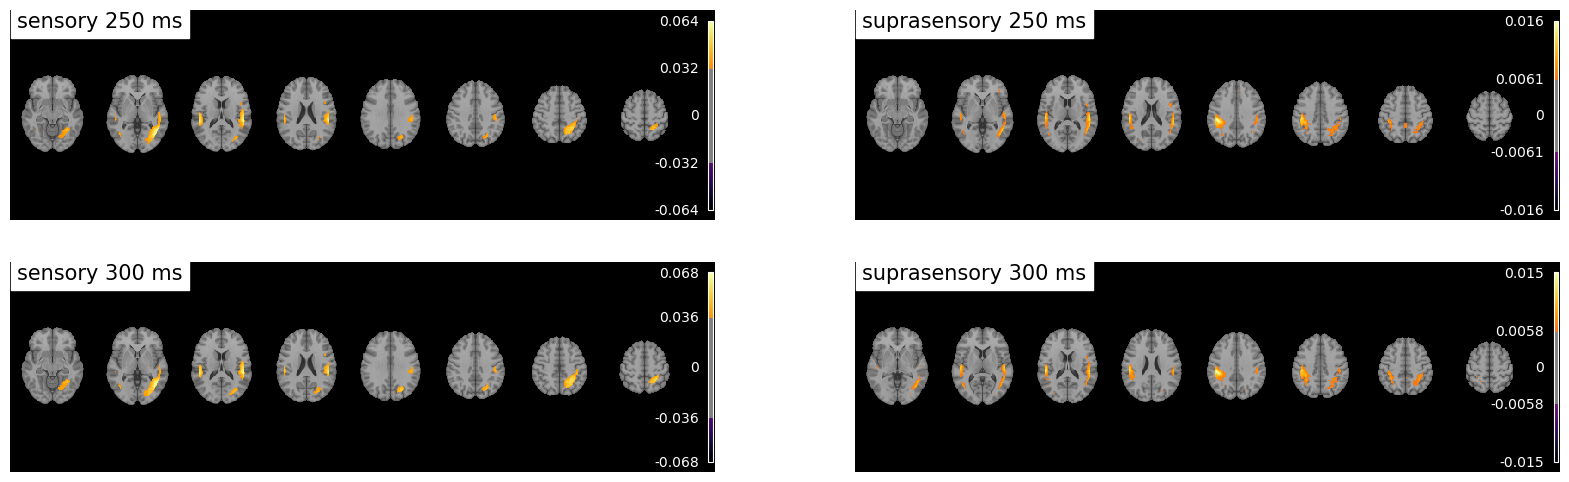

In [5]:
config_class_name = 'FusionConfig_C5'
meanMEG = True

full_data, mask = load_all_files(config_class_name, meanMEG)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)


### Config: C2

A) No MEG mean


Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default

Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default
Threshold: 95 %
sensory
suprasensory
Threshold: 99 %
sensory
suprasensory


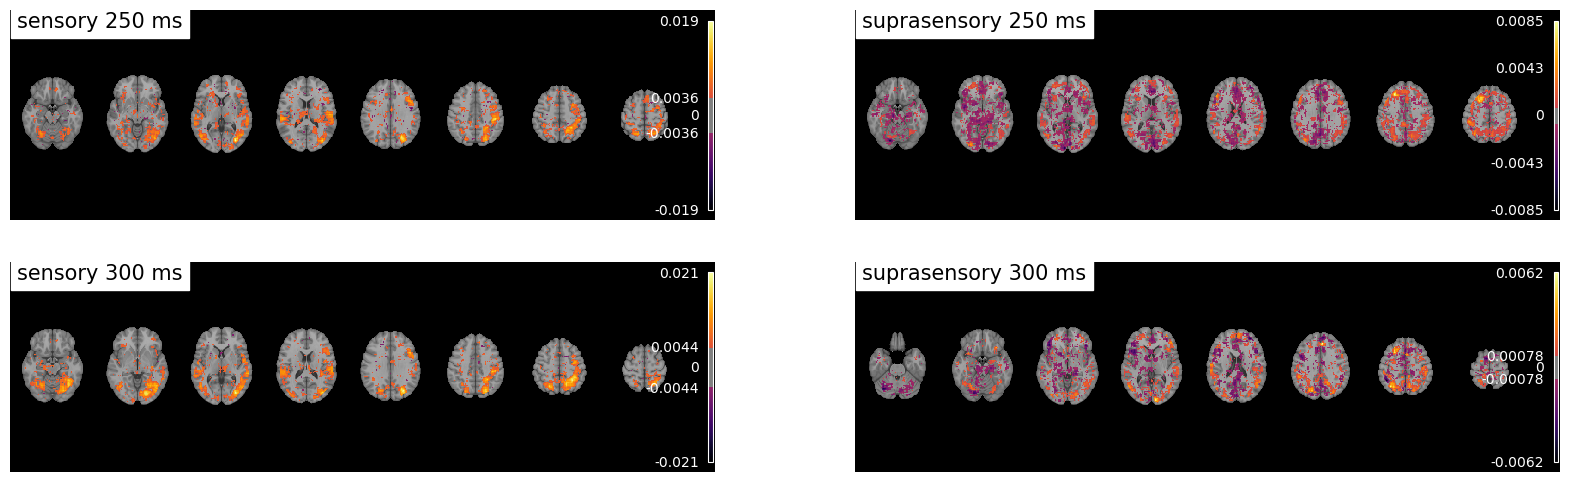

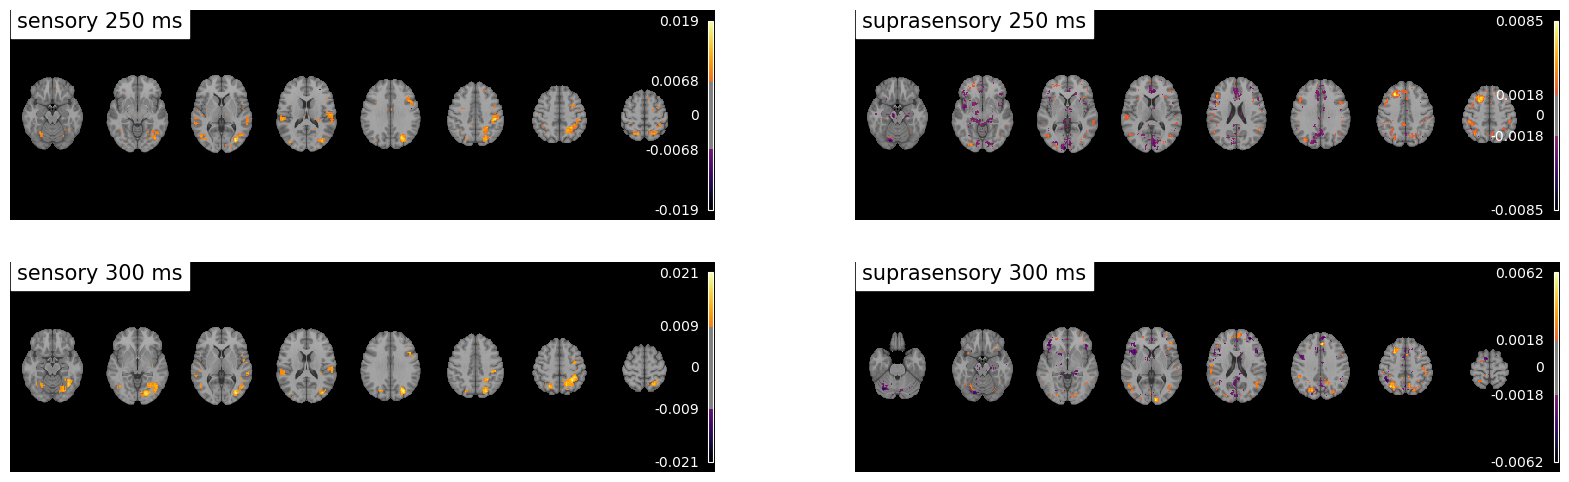

In [6]:
config_class_name = 'FusionConfig_C2'
meanMEG = False

full_data, mask = load_all_files(config_class_name, meanMEG)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)

B) MEG mean


Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default

Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default
Threshold: 95 %
sensory
suprasensory
Threshold: 99 %
sensory
suprasensory


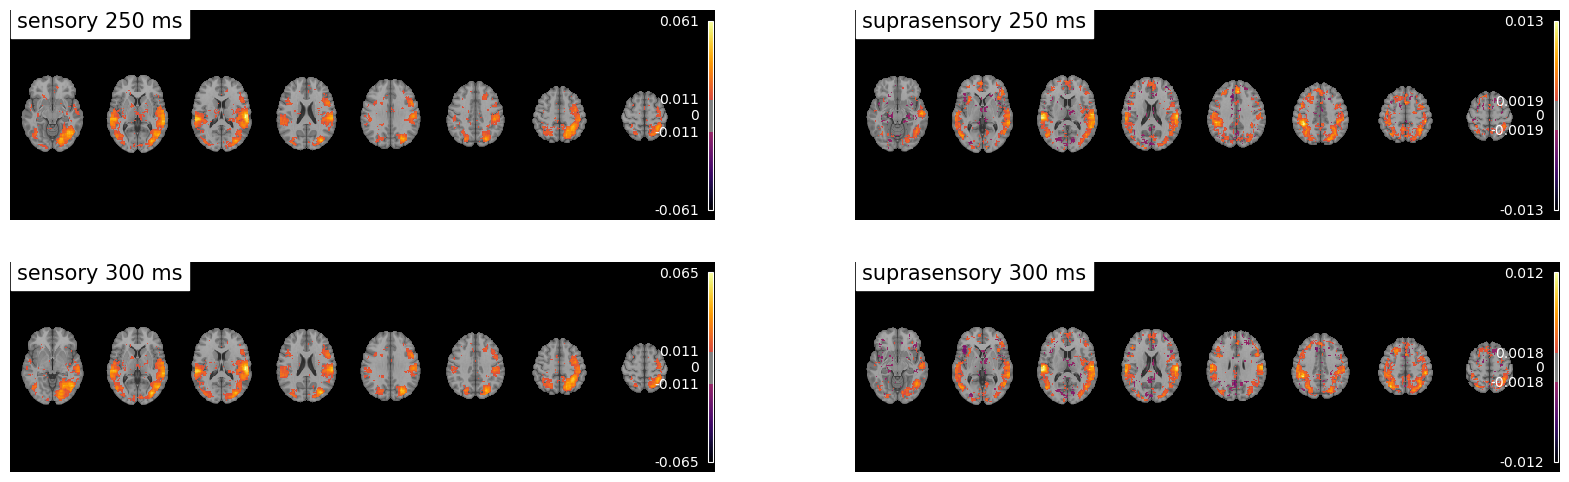

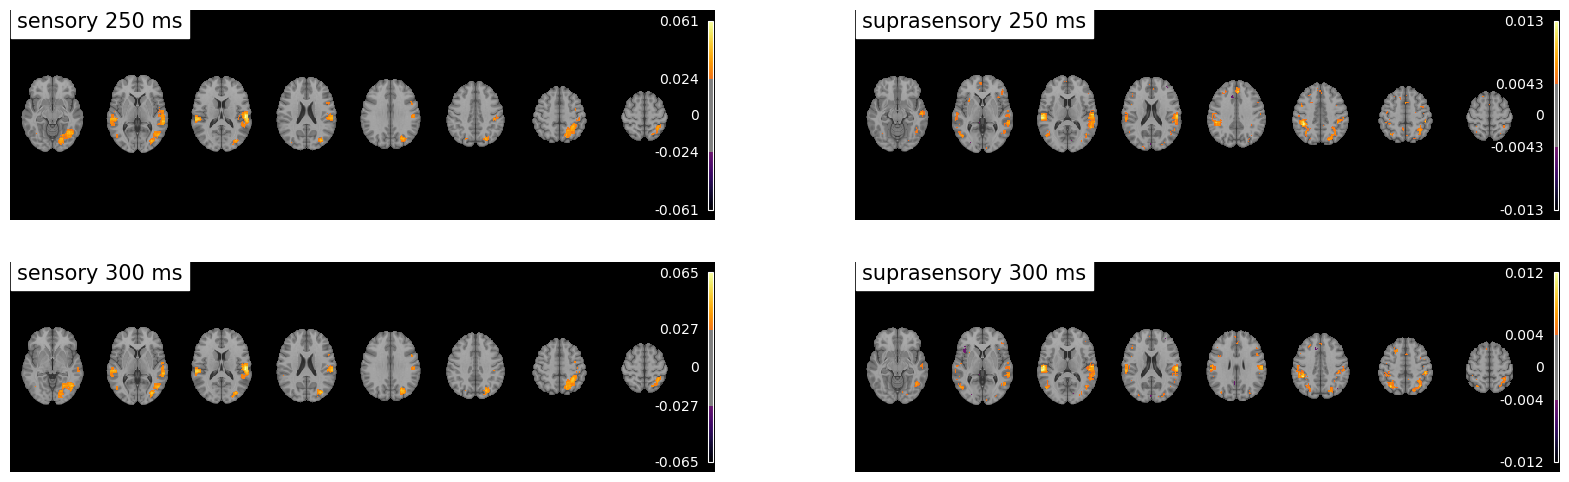

In [ ]:
config_class_name = 'FusionConfig_C2'
meanMEG = True

full_data, mask = load_all_files(config_class_name, meanMEG)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)

# Euclidean

### Config: E5

A) No MEG mean


Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default

Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default
number of subjects: 15


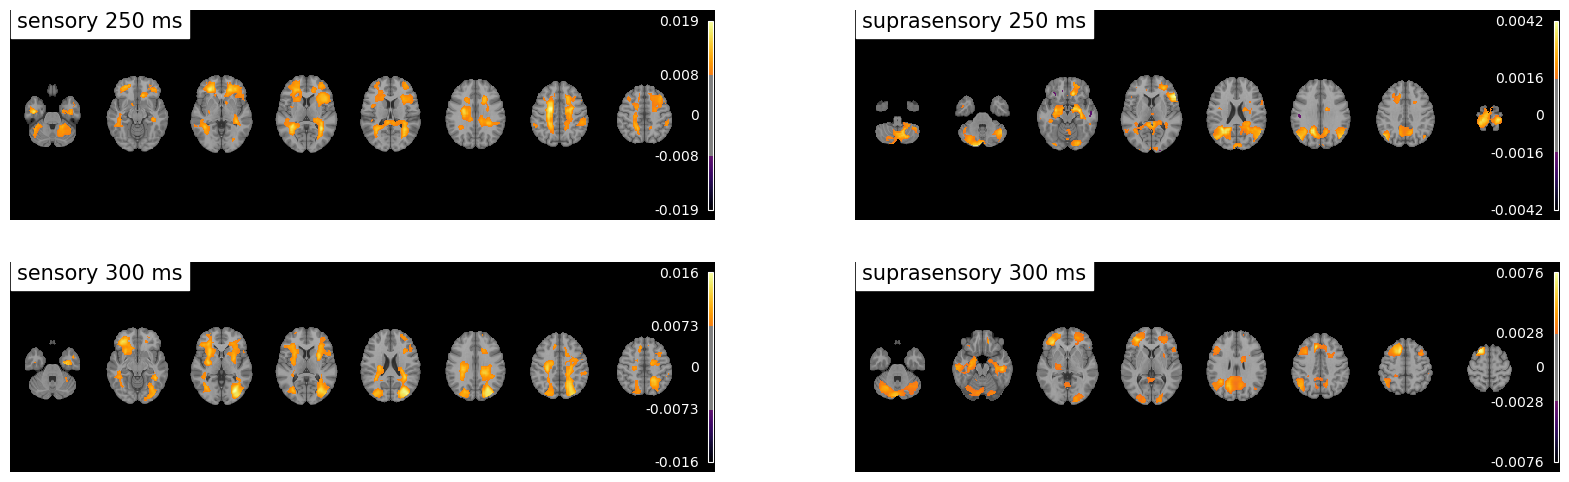

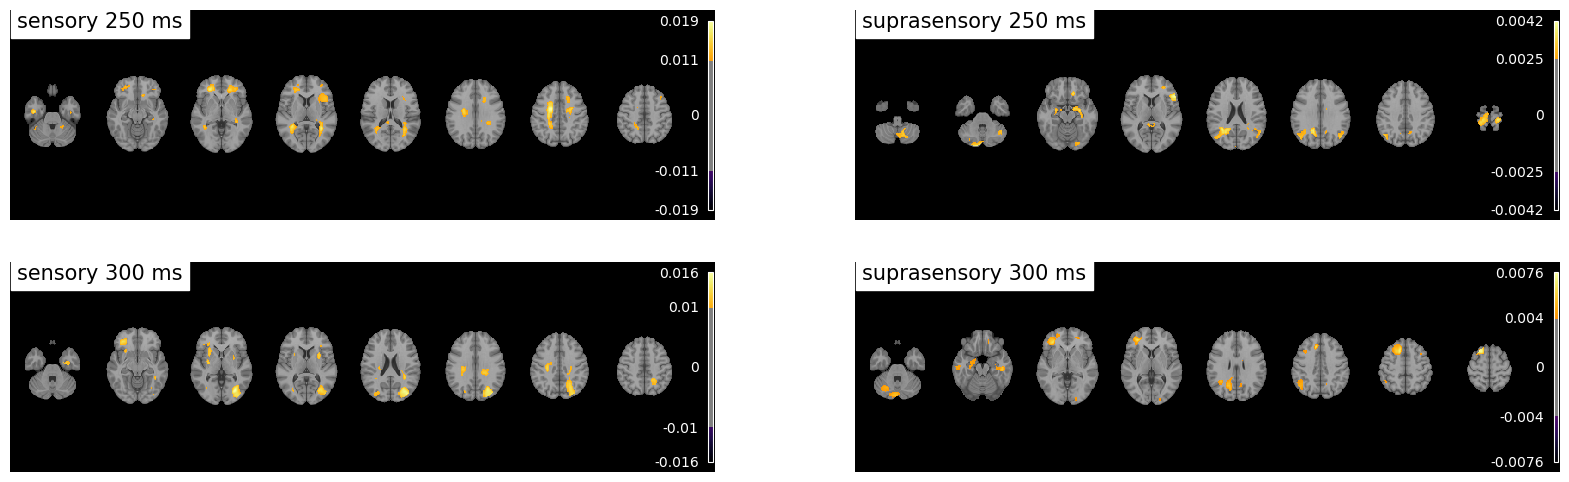

In [5]:
config_class_name = 'FusionConfig_E5'
meanMEG = False

full_data, mask = load_all_files(config_class_name, meanMEG)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)


B) MEG mean


Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default

Doing the "get_mask_file" method (probably while creating an instance of the MRI config class.No subjectID specified. Returning mask of subject "19910823ssld" as default
number of subjects: 16


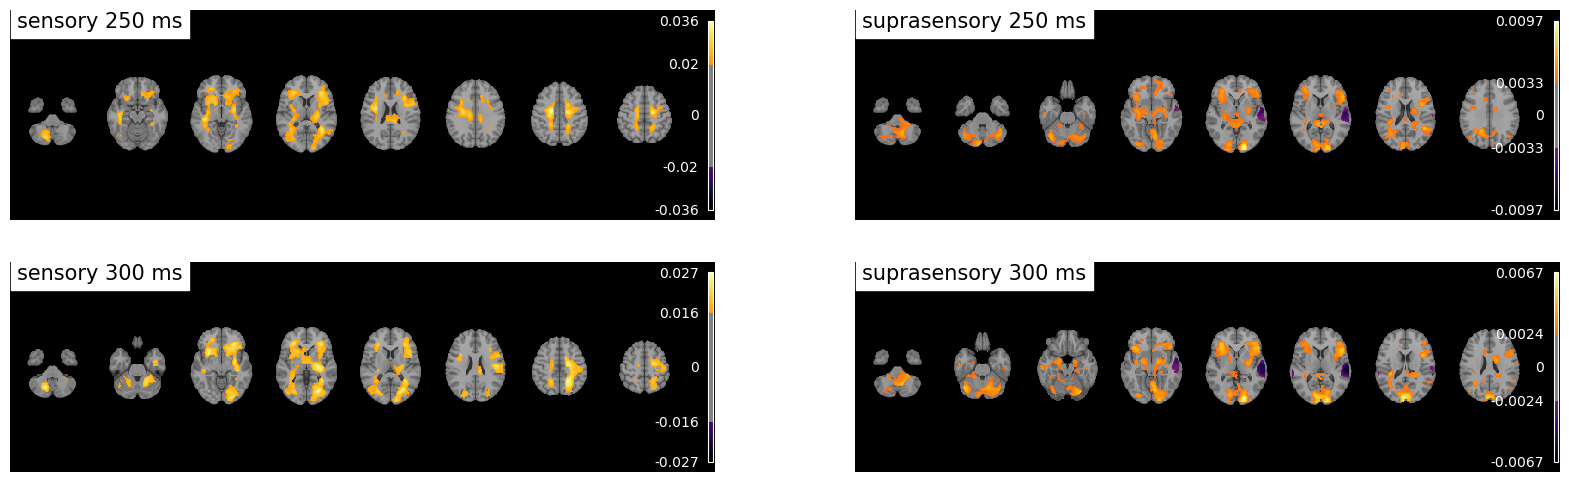

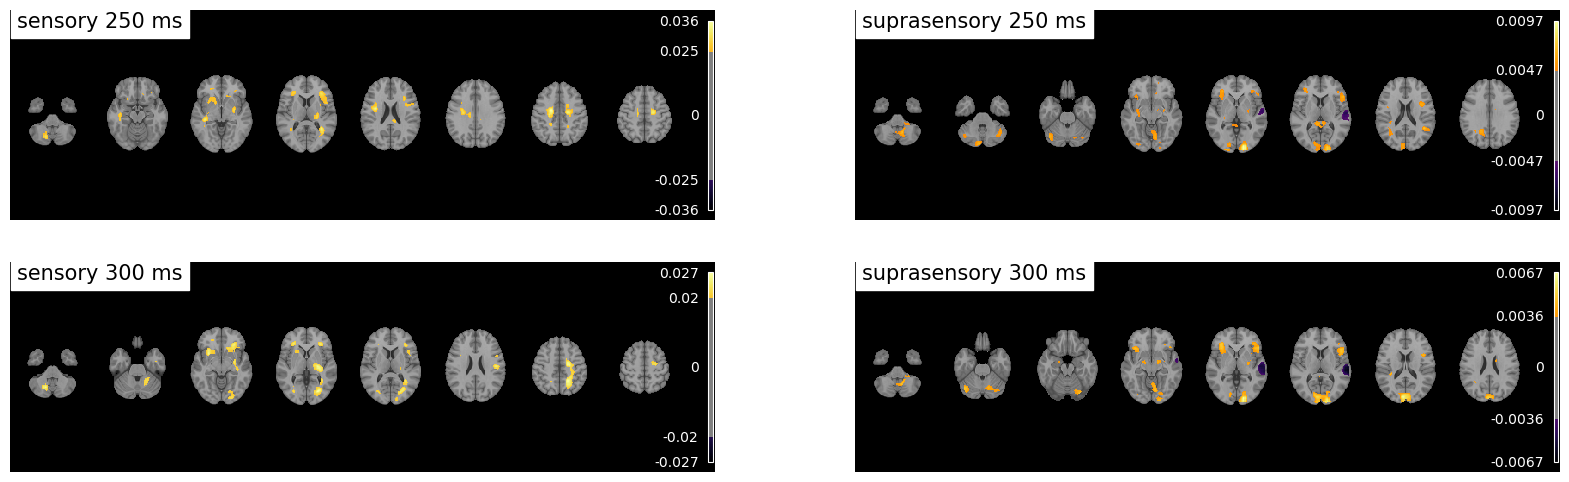

In [6]:
config_class_name = 'FusionConfig_E5'
meanMEG = True

full_data, mask = load_all_files(config_class_name, meanMEG)
len(full_data)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)

### Config: E2

A) No MEG mean

In [ ]:
config_class_name = 'FusionConfig_E2'
meanMEG = False

full_data, mask = load_all_files(config_class_name, meanMEG)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)


B) MEG mean

In [ ]:
config_class_name = 'FusionConfig_E2'
meanMEG = True

full_data, mask = load_all_files(config_class_name, meanMEG)

plot_workflow(full_data, mask, thres = [95, 99], plot_time = [125, 130], plot_ss_thr_masks = False, plot_mean_commonality = True)
